In [1]:
import numpy as np
import pandas as pd
from numba import jit

import matplotlib
matplotlib.rcParams['image.cmap'] = 'jet'
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.metrics import roc_auc_score

$$
D^{(-1)} W = I - L
$$

In [2]:
@jit(nopython=True, fastmath=True)
def compute_single_edge_grad(smat, uidx, iidx, udata, idata):
    r = smat - np.sum(udata[uidx, :] * idata[iidx, :])
    print('r = ' + str(r))
    ### what is the next step?
    dldu = - 2.0 * r * idata[iidx, :]
    dldi = - 2.0 * r * udata[uidx, :]
    return (dldu, dldi)

@jit(nopython=True, fastmath=True)
def compute_entire_grad(smat, uidx, iidx, udata, idata):
    ugrad = 0.0 * udata
    igrad = 0.0 * idata
    nedge = smat.size
    res = 0.0
    for idx in range(nedge):
        r = smat[idx] - np.sum(udata[uidx[idx], :] * idata[iidx[idx], :])
        res += r * r / nedge
        dldu = - 2.0 * r * idata[iidx[idx], :]
        dldi = - 2.0 * r * udata[uidx[idx], :]
        ugrad[uidx[idx], :] += dldu / nedge
        igrad[iidx[idx], :] += dldi / nedge
    return (ugrad, igrad, res)

@jit(nopython=True, fastmath=True)
def compute_batch_grad(smat, uidx, iidx, udata, idata, nbatch):
    nedge = smat.size
    eidx = np.random.randint(0, high=nedge, size=nbatch)
    ugrad = 0.0 * udata
    igrad = 0.0 * idata
    res = 0
    for ibatch in range(nbatch):
        idx = eidx[ibatch]
        r = smat[idx] - np.sum(udata[uidx[idx], :] * idata[iidx[idx], :])
        res += r * r / nbatch
        dldu = - 2.0 * r * idata[iidx[idx], :]
        dldi = - 2.0 * r * udata[uidx[idx], :]
        ugrad[uidx[idx], :] += dldu / nedge
        igrad[iidx[idx], :] += dldi / nedge
    return (ugrad, igrad, res)

def single_sgd_step(smat, uidx, iidx, udata, idata, dt, eidx): 
    # eidx = np.random.randint(0, high=smat.size)
    smat_val = smat[eidx]
    uidx_val = uidx[eidx]
    iidx_val = iidx[eidx]
    dldu, dldi = compute_single_edge_grad(smat_val, uidx_val, iidx_val,
                                          udata, idata)
    uembed = 0.0 + udata
    iembed = 0.0 + idata
    uembed[uidx, :] = uembed[uidx, :] - dt * dldu
    iembed[iidx, :] = iembed[iidx, :] - dt * dldi
    return (uembed, iembed)

# @jit(nopython=True, fastmath=True)
def svd_via_sgd(smat, uidx, iidx, nuser, nitem, dims, dt0, niter, nbatch, regf=1.0e-6):
    udata = np.random.normal(0.0, 1.0, (nuser, dims))
    idata = np.random.normal(0.0, 1.0, (nitem, dims))
    eidx = 0
    rdata = np.zeros((niter))
    for kiter in range(niter):
        eidx = np.random.randint(0.0, high=smat.size)
        dt = dt0 / np.sqrt(1.0 + kiter)
        # udata, idata = single_sgd_step(smat, uidx, iidx, 0.0 + udata, 0.0 + idata, dt, eidx)
        # ugrad, igrad = compute_entire_grad(smat, uidx, iidx, udata, idata)
        ugrad, igrad, res = compute_batch_grad(smat, uidx, iidx, udata, idata, nbatch)
        # print('res = ' + str(res))
        udata = udata - dt * ugrad - dt * regf * udata
        idata = idata - dt * igrad - dt * regf * idata
        rdata[kiter] = 0.0 + res
        print('rdata[' + str(kiter) + '] = ' + str(rdata[kiter]))
        # eidx = eidx + 1
        # eidx = eidx - smat.size * np.int64(eidx / smat.size)        
    return (udata, idata, rdata)

inside the main function
   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596
(100000, 4)
0
942
0
1681
[3 3 1 2 1 4 2 5 3 3]
nuser = 943
nitem = 1682
1
5


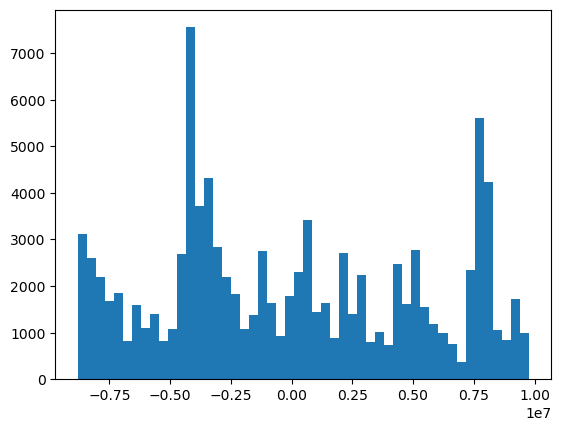

npos = 55375
nneg = 44625
rdata[0] = 5.816364504501374
rdata[1] = 6.049628773510131
rdata[2] = 5.675881378341574
rdata[3] = 6.605724203527936
rdata[4] = 5.465064934645112
rdata[5] = 6.216457369930403
rdata[6] = 5.8958458797485855
rdata[7] = 5.952749056163591
rdata[8] = 6.013928193552508
rdata[9] = 5.932577278042599
rdata[10] = 5.4750433569054895
rdata[11] = 5.8056050754650235
rdata[12] = 5.894410783726321
rdata[13] = 6.018487404276504
rdata[14] = 6.086448298062673
rdata[15] = 6.342135463517393
rdata[16] = 5.776159844664959
rdata[17] = 6.546032573158522
rdata[18] = 5.817955301439052
rdata[19] = 6.07509943980931
rdata[20] = 6.071925113901312
rdata[21] = 5.693266820665121
rdata[22] = 4.8929257331405305
rdata[23] = 5.86012894623089
rdata[24] = 6.240532261405675
rdata[25] = 5.989393972941918
rdata[26] = 5.817408899583382
rdata[27] = 5.564221897706764
rdata[28] = 5.9506853622574285
rdata[29] = 5.665249584996359
rdata[30] = 5.736294347282989
rdata[31] = 6.306049728442722
rdata[32] = 5.8271074

In [3]:
def get_positives_and_negatives(idata, rtarget):
    nedge = idata.shape[0]
    emat = np.zeros(nedge)
    uidx = np.zeros((nedge), dtype=np.int64)
    iidx = np.zeros((nedge), dtype=np.int64)
    nneg = 0
    npos = 0

    for idx in range(idata.shape[0]):
        uidx[idx] = idata[idx, 0]
        iidx[idx] = idata[idx, 1]
        if idata[idx, 2] >= rtarget:
            npos += 1
            emat[idx] = 1.0
        else:
            nneg += 1
            emat[idx] = 0.0
    print('npos = ' + str(npos))
    print('nneg = ' + str(nneg))
    return (emat, uidx, iidx)
    
def train_test_split(emat, uidx, iidx, timestemp_data, frac_train=0.7):
    t_threshold = np.quantile(timestemp_data, frac_train)
    nedge = emat.size
    emat_train = []
    uidx_train = []
    iidx_train = []
    emat_ttest = []
    uidx_ttest = []
    iidx_ttest = []
    for iedge in range(nedge):
        if timestemp_data[iedge] <= t_threshold:
            emat_train.append(emat[iedge])
            uidx_train.append(uidx[iedge])
            iidx_train.append(iidx[iedge])
        else:
            emat_ttest.append(emat[iedge])
            uidx_ttest.append(uidx[iedge])
            iidx_ttest.append(iidx[iedge])
    emat_train = np.asarray(emat_train, dtype=np.float64)
    uidx_train = np.asarray(uidx_train, dtype=np.int64)
    iidx_train = np.asarray(iidx_train, dtype=np.int64)

    emat_ttest = np.asarray(emat_ttest, dtype=np.float64)
    uidx_ttest = np.asarray(uidx_ttest, dtype=np.int64)
    iidx_ttest = np.asarray(iidx_ttest, dtype=np.int64)
    
    return (emat_train, uidx_train, iidx_train,
            emat_ttest, uidx_ttest, iidx_ttest)


def prepare_graph_laplacian(emat, uidx, iidx, nuser, nitem):
    nedge = emat.size
    wmat = np.zeros((2 * nedge))
    wid0 = np.zeros((2 * nedge), dtype=np.int64)
    wid1 = np.zeros((2 * nedge), dtype=np.int64)
    
    wmat[:nedge] = emat[:]
    wid0[:nedge] = uidx[:]
    wid1[:nedge] = nuser + iidx[:]
    wmat[nedge:] = emat[:]
    wid0[nedge:] = nuser + iidx[:]
    wid1[nedge:] = uidx[:]
    
    dval = np.zeros((nuser + nitem))
    for idx in range(wmat.size):
        dval[wid0[idx]] += wmat[idx]
    for idx in range(dval.size):
        dval[idx] = max(dval[idx], 1.0)
    for idx in range(wmat.size):
        wmat[idx] /= dval[wid0[idx]]
    return (wmat, wid0, wid1)

    
def main():
    print('inside the main function')
    ratings = pd.read_csv('./ml-100k/u.data', sep='\t', names=['user_id', 'movie_id', 'rating', 'timestamp'])
    print(ratings.head())
    idata = ratings.values
    print(idata.shape)
    idata[:, 0] -= 1
    idata[:, 1] -= 1
    nuser = np.max(idata[:, 0]) + 1
    nitem = np.max(idata[:, 1]) + 1
    print(np.min(idata[:, 0]))
    print(np.max(idata[:, 0]))
    print(np.min(idata[:, 1]))
    print(np.max(idata[:, 1]))
    print(idata[:10, 2])
    print('nuser = ' + str(nuser))
    print('nitem = ' + str(nitem))
    print(np.min(idata[:, 2]))
    print(np.max(idata[:, 2]))

    idata[:, 3] = idata[:, 3] - np.mean(idata[:, 3])
    plt.figure()
    plt.hist(idata[:, 3], bins=50)
    plt.show()
    rtarget = 4.0
    emat, uidx, iidx = get_positives_and_negatives(idata, rtarget)
    wmat, wid0, wid1 = prepare_graph_laplacian(emat, uidx, iidx, nuser, nitem)
    niter = 10000
    dims = 6
    dt0 = 10.0
    nbatch = 1024
    udata, ldata, rdata = svd_via_sgd(wmat, wid0, wid1, nuser + nitem, nuser + nitem, dims, dt0, niter, nbatch, regf=1.0e-6)    
    # for idx0 in range(dims):
    #     for idx1 in range(dims):
    #         plt.figure()
    #         plt.scatter(ldata[:, idx0], ldata[:, idx1])
    #         plt.grid()
    #         plt.show()
    # wmat_train, uidx_train, iidx_train, emat_ttest, uidx_ttest, iidx_ttest = train_test_split(emat, uidx, iidx, idata[:, 3], frac_train=0.7)
    
    
main()
